In [1]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))
print(tf.test.is_built_with_cuda())
# checking complete 

I0000 00:00:1778328596.430384    8781 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.21.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
True


In [5]:
!pip install opencv-python
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


In [2]:
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.model_selection import train_test_split
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [3]:
IMG_SIZE = 256
BATCH_SIZE = 2
EPOCHS = 100
DATA_PATH = '/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/DataSets/Kvasir-SEG'

In [4]:
def load_paths(data_path):
    images = sorted(glob.glob(os.path.join(data_path, 'images/*.jpg')))
    masks = sorted(glob.glob(os.path.join(data_path, 'masks/*.jpg')))
    return images, masks

In [5]:
print(load_paths(DATA_PATH))

(['/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/DataSets/Kvasir-SEG/images/cju0qkwl35piu0993l0dewei2.jpg', '/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/DataSets/Kvasir-SEG/images/cju0qoxqj9q6s0835b43399p4.jpg', '/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/DataSets/Kvasir-SEG/images/cju0qx73cjw570799j4n5cjze.jpg', '/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/DataSets/Kvasir-SEG/images/cju0roawvklrq0799vmjorwfv.jpg', '/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/DataSets/Kvasir-SEG/images/cju0rx1idathl0835detmsp84.jpg', '/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/DataSets/Kvasir-SEG/images/cju0s2a9ekvms080138tjjpxr.jpg', '/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/DataSets/Kvasir-SEG/images/cju0s690hkp960855tjuaqvv0.jpg', '/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/DataSets/Kvasir-SEG/images/cju0sr5ghl0nd08789uzf1raf.jpg', '/mnt/c/development/Thesis/PotatoDiseaseClassification

In [6]:
def process_path(img_path, mask_path):
    # Image Processing
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    # Mask processing
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_jpeg(mask, channels=1)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE])
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0) # ensuring binary masks
    return img, mask

In [7]:
def load_and_preprocess(image_path, mask_path):
    # ইমেজ লোড এবং রিসাইজ
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [256, 256]) # এখানে রিসাইজ নিশ্চিত করুন
    img = img / 255.0

    # মাস্ক লোড এবং রিসাইজ (অবশ্যই ইমেজের সাথে মিল থাকতে হবে)
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [256, 256])
    mask = mask / 255.0
    
    return img, mask

In [8]:
def get_dataset(x, y, batch=8):
    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    dataset = dataset.shuffle(buffer_size=100)
    dataset = dataset.map(process_path)
    dataset = dataset.batch(batch)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

In [9]:
# Unet Model Architecture
def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck
    b1 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    b1 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(b1)

    # Decoder
    u1 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(b1)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u1)

    u2 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c4)
    return models.Model(inputs, outputs, name="U-Net")

In [35]:
def test_and_display(model, image_path):
    # ইমেজ লোড
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    
    # মডেল ইনপুট
    img_input = np.expand_dims(img_resized / 255.0, axis=0)
    
    # ১. White Mask জেনারেট করা
    pred_mask = model.predict(img_input)[0]
    mask_binary = (pred_mask > 0.5).astype(np.uint8)
    
    # ২. অরিজিনাল ইমেজের ওপর মাস্ক বসিয়ে পলিপ বের করা
    mask_3d = cv2.merge([mask_binary, mask_binary, mask_binary])
    extracted_polyp = cv2.multiply(img_resized, mask_3d)

    # ডিসপ্লে
    titles = ['Original Image', 'White Mask (Polyp)', 'Extracted Polyp']
    images = [img_resized, pred_mask.squeeze(), extracted_polyp]

    plt.figure(figsize=(15, 5))
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(images[i], cmap='gray' if i==1 else None)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()


In [10]:
image_paths, mask_paths = load_paths(DATA_PATH)
train_x, val_x, train_y, val_y = train_test_split(image_paths, mask_paths, test_size=0.2, random_state=42)

train_ds = get_dataset(train_x, train_y, batch=BATCH_SIZE)
val_ds = get_dataset(val_x, val_y, batch=BATCH_SIZE)

W0000 00:00:1778328673.887168    8781 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1778328673.887210    8781 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1778328673.888127    8781 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [11]:
def dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    numerator = 2 * tf.reduce_sum(y_true * y_pred)
    denominator = tf.reduce_sum(y_true + y_pred)
    return 1 - (numerator + 1) / (denominator + 1)

In [12]:
data_path = DATA_PATH
image_list =sorted(glob.glob(os.path.join(data_path, 'images/*.jpg')))
mask_list =sorted(glob.glob(os.path.join(data_path, 'masks/*.jpg')))
# ১. স্লাইস তৈরি করা
dataset = tf.data.Dataset.from_tensor_slices((image_list, mask_list))

# ২. ম্যাপ (Map) ফাংশনের মাধ্যমে আপনার প্রি-প্রসেসিং ফাংশনটি অ্যাপ্লাই করা
dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# ৩. ব্যাচ এবং শাফেল (Shuffle) করা
TRAIN_SIZE = 800 # ১০০০ এর মধ্যে ৮০০ ট্রেইনিংয়ের জন্য
dataset = dataset.shuffle(1000)

train_ds = dataset.take(TRAIN_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = dataset.skip(TRAIN_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [13]:
unet = build_unet()
unet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # লার্নিং রেট একটু কমিয়ে দেওয়া ভালো
    loss=dice_loss, 
    metrics=['accuracy']
)
print("Training started...")

from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint(
    '/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/models/best_unet_model_v1.keras',     
    monitor='val_loss',         
    save_best_only=True,        
    mode='min'                 
)

history = unet.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=EPOCHS, 
    callbacks=[reduce_lr, early_stop, checkpoint]
)

history = unet.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=EPOCHS, 
    callbacks=[reduce_lr, early_stop]
)
print("Training complete!")


Training started...
Epoch 1/100


I0000 00:00:1778328702.147884    9402 service.cc:153] XLA service 0x7ab1d4007520 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778328702.147969    9402 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778328702.286612    9402 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778328703.044676    9402 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1778328729.921577    9402 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


400/400 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.6960 - loss: 0.9273 - val_accuracy: 0.8202 - val_loss: 0.9999 - learning_rate: 1.0000e-04
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.8431 - loss: 0.9999 - val_accuracy: 0.8269 - val_loss: 0.9999 - learning_rate: 1.0000e-04
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8367 - loss: 0.9999 - val_accuracy: 0.8408 - val_loss: 0.9999 - learning_rate: 1.0000e-04
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8392 - loss: 0.9999 - val_accuracy: 0.8344 - val_loss: 0.9999 - learning_rate: 1.0000e-04
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8412 - loss: 0.9999 - val_accuracy: 0.8537 - val_loss: 0.9999 - learning_rate: 1.0000e-04
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.8369 - loss: 0.9999 - val_accuracy: 0.8439 - val_loss: 0.9999 - learning_rate: 1.0000e-04
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - a

KeyboardInterrupt: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


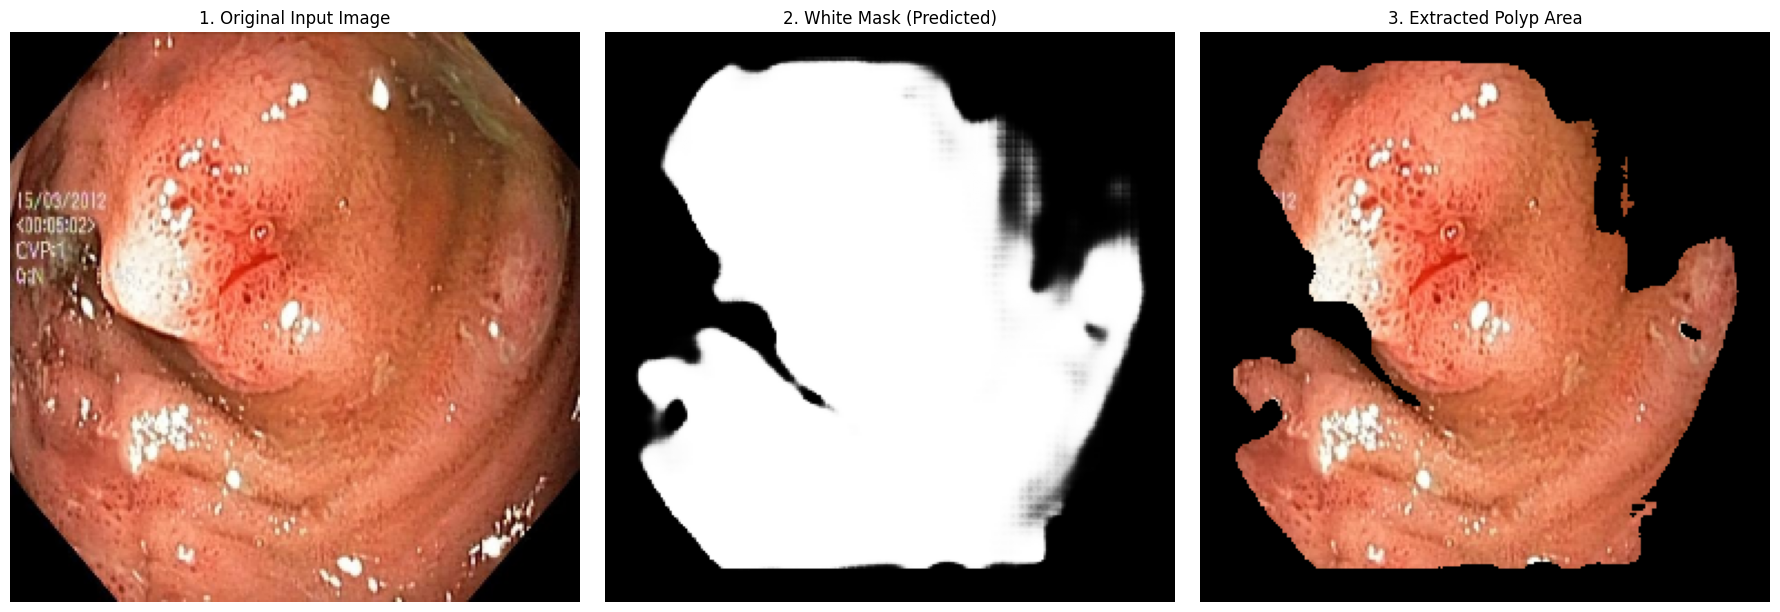

In [44]:
import matplotlib.pyplot as plt

def test_and_display(image_path):
    # ১. ইমেজ লোড এবং প্রি-প্রসেস
    if not os.path.exists(image_path):
        print("ভুল পাথ! ইমেজটি খুঁজে পাওয়া যায়নি।")
        return

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # OpenCV BGR এ লোড করে, তাই RGB তে কনভার্ট করতে হবে
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    
    # মডেলের জন্য নরমালাইজেশন
    img_input = np.expand_dims(img_resized / 255.0, axis=0)

    # ২. স্টেপ-১: সেগমেন্টেশন (সাদা-কালো মাস্ক তৈরি)
    pred_mask = unet.predict(img_input)[0] 
    
    # ৩. স্টেপ-২: এক্সট্রাকশন (অরিজিনাল ইমেজের ওপর মাস্ক বসানো)
    # মাস্কটিকে বাইনারি থ্রেশহোল্ড করা (০.৫ এর উপরে হলে ১, নিচে হলে ০)
    mask_binary = (pred_mask > 0.5).astype(np.uint8)
    # ৩ চ্যানেলে রূপান্তর যেন রঙিন ছবির সাথে মাস্ক করা যায়
    mask_3d = cv2.merge([mask_binary, mask_binary, mask_binary])
    # মাস্কিং অপারেশন
    extracted_polyp = cv2.multiply(img_resized, mask_3d)

    # ৪. ইমেজগুলো ডিসপ্লে করা
    plt.figure(figsize=(18, 6))

    # অরিজিনাল ইনপুট ইমেজ
    plt.subplot(1, 3, 1)
    plt.imshow(img_resized)
    plt.title("1. Original Input Image")
    plt.axis('off')

    # জেনারেটেড সাদা মাস্ক
    plt.subplot(1, 3, 2)
    plt.imshow(pred_mask.squeeze(), cmap='gray')
    plt.title("2. White Mask (Predicted)")
    plt.axis('off')

    # এক্সট্রাক্ট করা শুধু পলিপ অংশ
    plt.subplot(1, 3, 3)
    plt.imshow(extracted_polyp)
    plt.title("3. Extracted Polyp Area")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# ৫. রান করার নিয়ম:
# আপনার পিসিতে থাকা একটি পলিপ ইমেজের পাথ এখানে দিন
test_image_path = '/mnt/c/development/Thesis/PotatoDiseaseClassification-CNN/DataSets/Kvasir-SEG/images/cju0qkwl35piu0993l0dewei2.jpg' 
test_and_display(test_image_path)